# Demo

This notebook demonstrates how you can use `lazycogs` to lazily load massive arrays of Level 2 data from STAC metadata with cloud-optimized geotiff assets.

In [1]:
from pathlib import Path

import rustac
from pyproj import Transformer

import lazycogs

Define the area of interest with a CRS and a bounding box.

In [2]:
# define the AOI in/ a projection that is suitable for your analysis
dst_crs = "epsg:5070"
dst_bbox = (-700_000, 2_220_000, 600_000, 2_930_000)

# transform to epsg:4326 for STAC search
transformer = Transformer.from_crs(dst_crs, "epsg:4326", always_xy=True)
bbox_4326 = transformer.transform_bounds(*dst_bbox)

Query a STAC API and cache the result to a local stac-geoparquet file using `rustac`. This file will be used by the `lazycogs` backend to determine which COGs are required for which array operations.

This example generates an archive of Sentinel 2 Level 2A items for the summer months of 2025 for an area that covers a large part of Minnesota, USA.

In [3]:
items_parquet = "/tmp/midwest_summer_2025_items.parquet"

if not Path(items_parquet).exists():
    await rustac.search_to(
        items_parquet,
        href="https://earth-search.aws.element84.com/v1",
        collections=["sentinel-2-c1-l2a"],
        datetime="2025-06-01/2025-09-30",
        bbox=bbox_4326,
        limit=100,
    )

Open a 100% lazy `DataArray` representation of the assets referenced in the stac-geoparquet file for your specified CRS and bounding box and resolution. 

In [4]:
da = await lazycogs.open_async(
    items_parquet,
    crs=dst_crs,
    bbox=dst_bbox,
    resolution=100,
    time_period="P1D",
    bands=["red", "green", "blue"],
    dtype="int16",
)

da

<xarray.DataArray (band: 3, time: 121, y: 7100, x: 13000)> Size: 67GB
[33504900000 values with dtype=int16]
Coordinates:
  * band     (band) <U5 60B 'red' 'green' 'blue'
  * time     (time) datetime64[s] 968B 2025-06-01 2025-06-02 ... 2025-09-30
  * y        (y) float64 57kB 2.22e+06 2.22e+06 2.22e+06 ... 2.93e+06 2.93e+06
  * x        (x) float64 104kB -7e+05 -6.998e+05 -6.998e+05 ... 5.998e+05 6e+05
Attributes:
    _stac_backends:     [StacBackendArray(band='red', shape=(121, 7100, 13000...
    _stac_time_coords:  TimeCoords([2025-06-01 … 2025-09-30], n=121)

Get all of the values from June for a single point. Add `chunk(time=1, band=1)` to parallelize across time coordinates and bands.

In [5]:
%%time
(
    da.sel(x=299965, y=2653947, method="nearest")
    .sel(time=slice("2025-06-01", "2025-06-30"))
    .chunk(time=1, band=1)
    .compute()
)

CPU times: user 1min, sys: 5.85 s, total: 1min 6s
Wall time: 14.7 s


<xarray.DataArray (band: 3, time: 30)> Size: 180B
array([[    0,  2401,     0,  2450,     0, 10204,  2305,     0, 11972,
            0,     0,  8694,     0,  8674,     0,     0,  3526,     0,
        11815,     0,     0,  8288,     0,  2338,     0,  8155, 11156,
            0,  2371,     0],
       [    0,  2325,     0,  2318,     0, 10313,  2220,     0, 12910,
            0,     0,  8988,     0,  8427,     0,     0,  3565,     0,
        12537,     0,     0,  8400,     0,  2232,     0,  8063, 11271,
            0,  2358,     0],
       [    0,  2197,     0,  2138,     0, 10779,  2028,     0, 14624,
            0,     0,  9418,     0,  8392,     0,     0,  3418,     0,
        13905,     0,     0,  8836,     0,  2027,     0,  8020, 11703,
            0,  2159,     0]], dtype=int16)
Coordinates:
  * band     (band) <U5 60B 'red' 'green' 'blue'
  * time     (time) datetime64[s] 240B 2025-06-01 2025-06-02 ... 2025-06-30
    y        float64 8B 2.654e+06
    x        float64 8B 3e+05
Attributes:
    _stac_backends:     [StacBackendArray(band='red', shape=(121, 7100, 13000...
    _stac_time_coords:  TimeCoords([2025-06-01 … 2025-09-30], n=121)

Select a spatial subset

In [6]:
subset = da.sel(
    x=slice(100_000, 400_000),
    y=slice(2_600_000, 2_800_000),
)
subset

<xarray.DataArray (band: 3, time: 121, y: 2000, x: 3000)> Size: 4GB
[2178000000 values with dtype=int16]
Coordinates:
  * band     (band) <U5 60B 'red' 'green' 'blue'
  * time     (time) datetime64[s] 968B 2025-06-01 2025-06-02 ... 2025-09-30
  * y        (y) float64 16kB 2.6e+06 2.6e+06 2.6e+06 ... 2.8e+06 2.8e+06
  * x        (x) float64 24kB 1e+05 1.002e+05 1.002e+05 ... 3.998e+05 4e+05
Attributes:
    _stac_backends:     [StacBackendArray(band='red', shape=(121, 7100, 13000...
    _stac_time_coords:  TimeCoords([2025-06-01 … 2025-09-30], n=121)

Extract the values for a single point

In [7]:
%%time
subset.isel(time=1, x=0, y=0).compute()

CPU times: user 804 ms, sys: 131 ms, total: 935 ms
Wall time: 1.43 s


<xarray.DataArray (band: 3)> Size: 6B
array([1690, 1920, 1661], dtype=int16)
Coordinates:
  * band     (band) <U5 60B 'red' 'green' 'blue'
    time     datetime64[s] 8B 2025-06-02
    y        float64 8B 2.6e+06
    x        float64 8B 1e+05
Attributes:
    _stac_backends:     [StacBackendArray(band='red', shape=(121, 7100, 13000...
    _stac_time_coords:  TimeCoords([2025-06-01 … 2025-09-30], n=121)

Use the `stac_cog.explain()` accessor to learn about the underlying assets that will need to be accessed for a particular query.

In [8]:
plan = subset.isel(time=slice(1, 4)).lazycogs.explain()
print(plan.summary())

=== ExplainPlan ===
Parquet:    /tmp/midwest_summer_2025_items.parquet
CRS:        epsg:5070  |  Resolution: 100.0 units/px  |  Grid: 3000 x 2000 px
Bands (3):  red, green, blue
Time steps: 3 (2025-06-02 - 2025-06-04)
Chunks:     3000 x 2000 px -> 1x1 spatial tiles

Total chunk reads:     9 (3 band(s) x 3 time step(s) x 1 spatial tile(s))
Total COG reads:       57
Chunks with 0 COGs:       3 (33.3%)
Chunks with 1 COG:        0 (0.0%)
Chunks with 2+ COGs:      6 (66.7%)
Max COGs per chunk:    12
(Pass fetch_headers=True to see overview levels and pixel windows.)


Plot an RGB image of the subset area

Estimated peak in-flight memory for bands=['red', 'green', 'blue'] is ~824 MB (12 concurrent reads × 3 bands × 3000x2000 px). Lower max_concurrent_reads or add spatial chunks to reduce memory use.


CPU times: user 27.1 s, sys: 2.95 s, total: 30 s
Wall time: 14.7 s


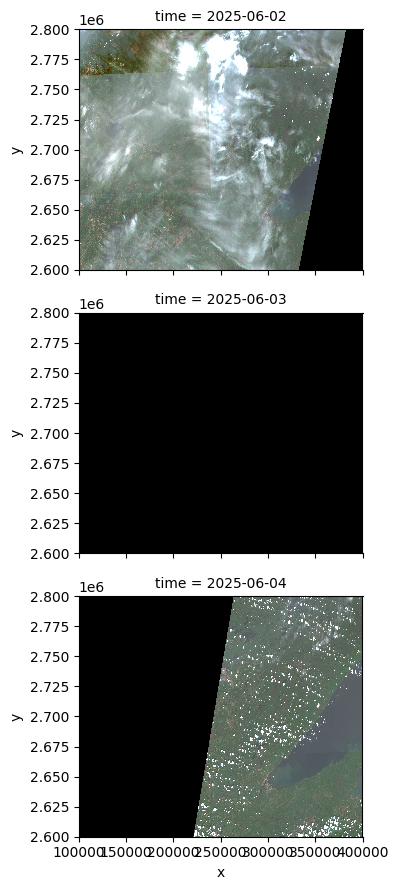

In [9]:
%%time
subset.isel(time=slice(1, 4)).plot.imshow(rgb="band", row="time", vmin=0, vmax=4000)

Use dask to split band/time into separate chunks.

CPU times: user 2min 46s, sys: 1min 43s, total: 4min 29s
Wall time: 24.8 s


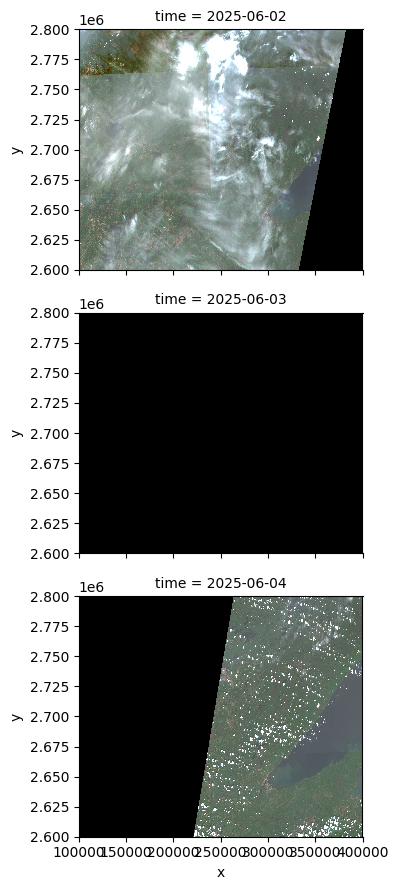

In [11]:
%%time
(
    subset.isel(time=slice(1, 4))
    .chunk(time=1, band=1)
    .plot.imshow(rgb="band", row="time", vmin=0, vmax=4000)
)

In [12]:
# define the AOI in/ a projection that is suitable for your analysis
dst_crs = "epsg:3310"
dst_bbox = (-444000, -609000, 681000, 500000)

# transform to epsg:4326 for STAC search
transformer = Transformer.from_crs(dst_crs, "epsg:4326", always_xy=True)
bbox_4326 = transformer.transform_bounds(*dst_bbox)

ca_items_parquet = "/tmp/ca_spring_2025_items.parquet"

if not Path(ca_items_parquet).exists():
    await rustac.search_to(
        ca_items_parquet,
        href="https://earth-search.aws.element84.com/v1",
        collections=["sentinel-2-c1-l2a"],
        datetime="2025-03-01/2025-06-30",
        bbox=bbox_4326,
        limit=100,
    )

Open an array 

In [19]:
ca_monthly = await lazycogs.open_async(
    ca_items_parquet,
    crs=dst_crs,
    bbox=dst_bbox,
    resolution=300,
    time_period="P1M",
    bands=["red", "green", "blue"],
    dtype="int16",
    filter="eo:cloud_cover < 50",
    sort_by="eo:cloud_cover",
)

ca_monthly

<xarray.DataArray (band: 3, time: 4, y: 3697, x: 3750)> Size: 333MB
[166365000 values with dtype=int16]
Coordinates:
  * band     (band) <U5 60B 'red' 'green' 'blue'
  * time     (time) datetime64[s] 32B 2025-03-01 2025-04-01 ... 2025-06-01
  * y        (y) float64 30kB -6.088e+05 -6.086e+05 ... 4.996e+05 5e+05
  * x        (x) float64 30kB -4.438e+05 -4.436e+05 ... 6.806e+05 6.808e+05
Attributes:
    _stac_backends:     [StacBackendArray(band='red', shape=(4, 3697, 3750)),...
    _stac_time_coords:  TimeCoords([2025-03-01 … 2025-06-01], n=4)

In [20]:
ca_may = ca_monthly.chunk(band=1, x=1024, y=1024).sel(time="2025-05-01")
ca_may

<xarray.DataArray (band: 3, y: 3697, x: 3750)> Size: 83MB
dask.array<getitem, shape=(3, 3697, 3750), dtype=int16, chunksize=(1, 1024, 1024), chunktype=numpy.ndarray>
Coordinates:
  * band     (band) <U5 60B 'red' 'green' 'blue'
  * y        (y) float64 30kB -6.088e+05 -6.086e+05 ... 4.996e+05 5e+05
  * x        (x) float64 30kB -4.438e+05 -4.436e+05 ... 6.806e+05 6.808e+05
    time     datetime64[s] 8B 2025-05-01
Attributes:
    _stac_backends:     [StacBackendArray(band='red', shape=(4, 3697, 3750)),...
    _stac_time_coords:  TimeCoords([2025-03-01 … 2025-06-01], n=4)

In [21]:
plan = ca_may.lazycogs.explain()

print(plan.summary())

=== ExplainPlan ===
Parquet:    /tmp/ca_spring_2025_items.parquet
CRS:        epsg:3310  |  Resolution: 300.0 units/px  |  Grid: 3750 x 3697 px
Bands (3):  red, green, blue
Time steps: 1 (2025-05-01)
Chunks:     1024 x 1024 px -> 4x4 spatial tiles

Total chunk reads:     48 (3 band(s) x 1 time step(s) x 16 spatial tile(s))
Total COG reads:       8862
Chunks with 0 COGs:       0 (0.0%)
Chunks with 1 COG:        0 (0.0%)
Chunks with 2+ COGs:     48 (100.0%)
Max COGs per chunk:    333
(Pass fetch_headers=True to see overview levels and pixel windows.)


In [22]:
%%time
from dask.diagnostics import ProgressBar

with ProgressBar():
    ca_may.load()

[########################################] | 100% Completed | 256.77 s
CPU times: user 6min 38s, sys: 1min 32s, total: 8min 10s
Wall time: 4min 16s


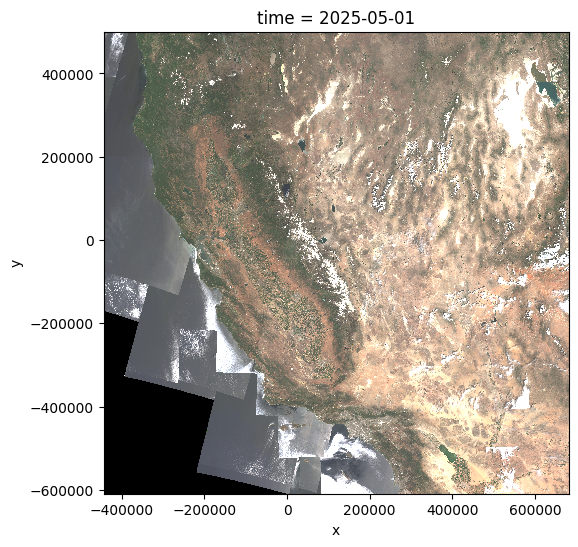

In [18]:
ca_may.plot.imshow(
    rgb="band",
    vmin=0,
    vmax=4000,
    figsize=(6, 6),
)